---
<a id='ejercicios'></a>
Alumna: Sandra Geraldine Castillo Dorantes
# 🎯 Ejercicios Integradores

Cada ejercicio combina los dos módulos: primero detección clásica,
luego la transformación apropiada para mejorar el análisis.

| Ejercicio | Escenario | Detección | Transformación |
|---|---|---|---|
| **1** | Daños a terceros (severidad con ceros) | IQR + Z-Mod | `arcsinh`, `√x`, `log(x+1)` |
| **2** | Vida grupo por sucursal (frecuencia) | IQR por sucursal | `√x` + `arcsin(√p)` + IC 95% |
| **3** | Hogar: frecuencia + severidad | IQR en ambas dim. | `√x` (freq) + `arcsinh` (sev) |

---
## Ejercicio 1 — Severidad Daños a Terceros con Ceros

**Enunciado**

Una aseguradora tiene 180 siniestros de daños a terceros. Algunos fueron rechazados (monto = 0).

1. Detecta outliers con IQR y Z-Score Modificado en escala original
2. Aplica `√x`, `arcsinh(x/mediana)` y `log(x+1)` a los montos
3. Calcula asimetría (skewness) en cada escala y construye QQ-plots
4. Detecta outliers con IQR en cada escala transformada y compara
5. Calcula la prima pura con y sin outliers
6. ¿Cuál transformación es más apropiada para esta distribución?

**Pista**: Para arcsinh usa como referencia la mediana de los montos > 0.


In [1]:
# =============================
# ========= LIBRERIAS =========
# =============================
import pandas as pd
import numpy as np
from scipy.stats import median_abs_deviation
import matplotlib.pyplot as plt
from scipy import stats

N total    : 180
Ceros      : 10
No-ceros   : 170
Skewness   : 4.522
Max        : $200,000

============== SOLUCION EJERCICIO 1 ===================

Hacemos una observacion de nuestros datos
El 5.56% de los datos son cero
Solo consideraremos siniestros mayores a cero

===== OUTLIERS USANDO IQR ======
Dato numero 1 - Valor: 15,368.19
Dato numero 32 - Valor: 17,070.68
Dato numero 57 - Valor: 27,248.46
Dato numero 160 - Valor: 95,000.0
Dato numero 161 - Valor: 120,000.0
Dato numero 162 - Valor: 85,000.0
Dato numero 163 - Valor: 140,000.0
Dato numero 164 - Valor: 200,000.0
Dato numero 165 - Valor: 75,000.0
Dato numero 166 - Valor: 160,000.0
Dato numero 167 - Valor: 110,000.0
Dato numero 168 - Valor: 180,000.0
Dato numero 169 - Valor: 95,500.0
Total de Outliers: 13

===== OUTLIERS USANDO Z SCORE MODIFICADO ======
Dato numero 1 - Valor: $15,368.19 - Z Score: 3.66
Dato numero 32 - Valor: $17,070.68 - Z Score: 4.22
Dato numero 57 - Valor: $27,248.46 - Z Score: 7.61
Dato numero 160 - Valor: $95

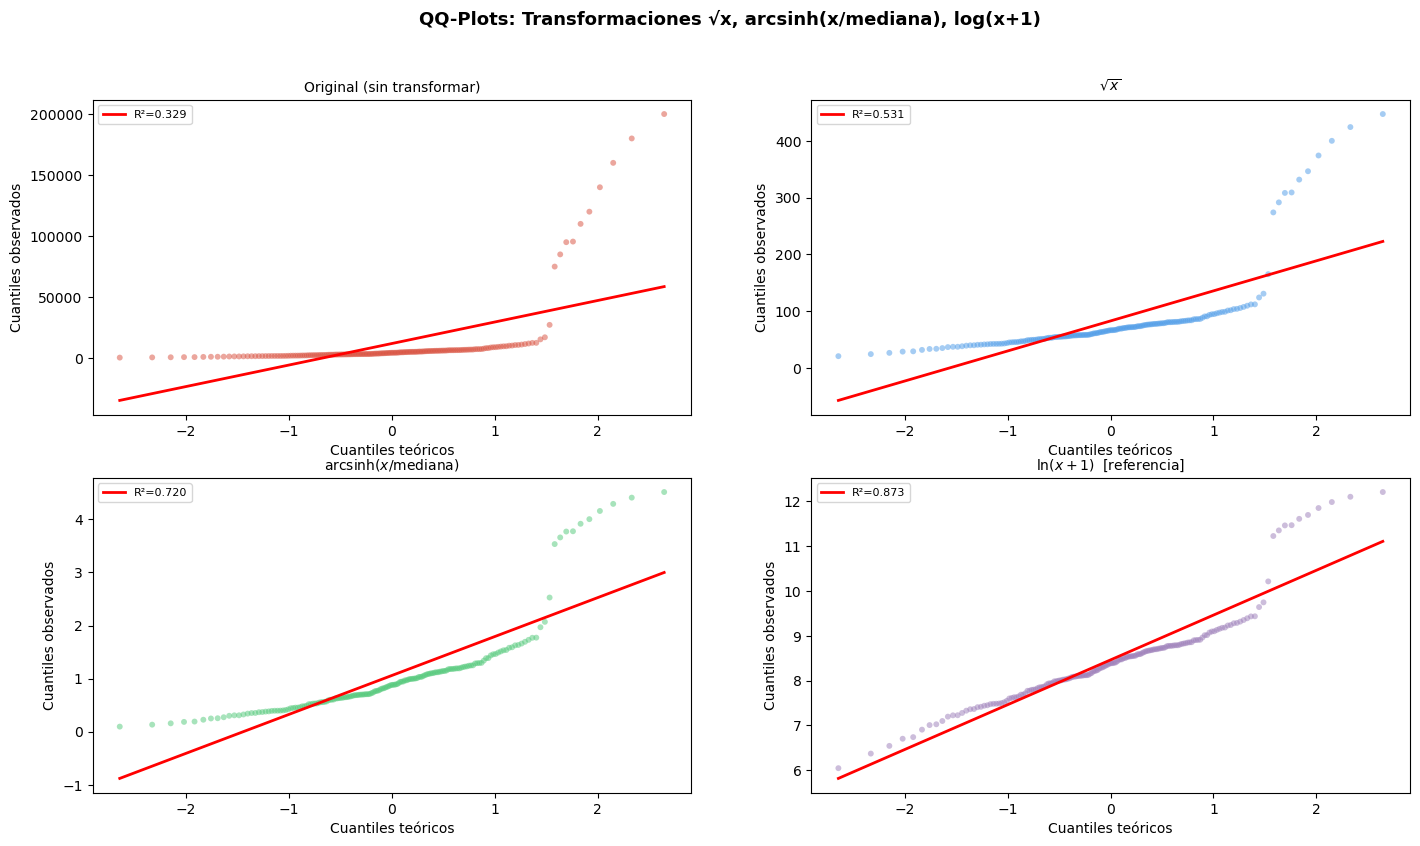

In [2]:
# ============================================================
# EJERCICIO 1 — Datos (no modificar)
# ============================================================
np.random.seed(99)
siniestros_base = np.random.lognormal(8.2, 0.7, 160)
siniestros_altos = np.array([95_000,120_000,85_000,140_000,200_000,
                               75_000,160_000,110_000,180_000,95_500])
ceros_ej1 = np.zeros(10)   # siniestros rechazados

siniestros_ej1 = pd.Series(
    np.concatenate([siniestros_base, siniestros_altos, ceros_ej1])
).round(2)

print(f'N total    : {len(siniestros_ej1)}')
print(f'Ceros      : {(siniestros_ej1==0).sum()}')
print(f'No-ceros   : {(siniestros_ej1>0).sum()}')
print(f'Skewness   : {siniestros_ej1.skew():.3f}')
print(f'Max        : ${siniestros_ej1.max():,.0f}')

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

print()
print("=======================================================")
print("============== SOLUCION EJERCICIO 1 ===================")
print("=======================================================")
print()

# ==================================================
# ==== 1. OUTLIERS CON IQR Y Z SCORE MODIFICADO ====
#===================================================

# Analisis inicial de los datos
print("Hacemos una observacion de nuestros datos")
# Observemos que porcentaje de nuestros datos son ceros
print(f"El {round(sum(siniestros_ej1 == 0)/len(siniestros_ej1)*100,2)}% de los datos son cero")
# No es un porcentaje muy grande, sin embargo, sería conveniente quitarlos para que no alteren
# los resultados y para que los outliers se calculen sobre montos que representan un gasto real
print("Solo consideraremos siniestros mayores a cero")
print()

# Usamos la siguiente linea para eliminar los siniestros igual a cero
siniestros1 = siniestros_ej1[siniestros_ej1>0].reset_index(drop=True)
# Podemos descomentar la siguiente linea si queremos mantener los ceros
# siniestros1 = siniestros_ej1.copy()

# ================== IQR ==================

# Definimos una funcion que calcule los ouliers usando IQR
def iqr(datos, mult = 1.5):
    Q1 = np.percentile(datos, 25)
    Q3 = np.percentile(datos, 75)
    IQR = Q3 - Q1
    # Se definen los limites
    limite_inferior = Q1 - mult * IQR
    limite_superior = Q3 + mult * IQR
    # Consideramos los datos dentro de esos limites
    outliers_mask = (datos < limite_inferior) | (datos > limite_superior)
    # Devolvemos los datos y su posicion
    return datos[outliers_mask], np.where(outliers_mask)[0]

out1_iqr, ind1_iqr = iqr(siniestros1)

print("===== OUTLIERS USANDO IQR ======")
for i,j in zip(out1_iqr, ind1_iqr):
    print(f"Dato numero {j} - Valor: {i:,}")
print(f"Total de Outliers: {len(out1_iqr)}")
print()

# =============== Z SCORE MODIFICADO ===============

# Definimos una funcion que calcule los ouliers usando Z Score Modificado
def zs_mod(datos, umbral, mult = 0.6745):
    mediana = np.median(datos)
    desv = mult * abs(datos - mediana)
    mad = median_abs_deviation(datos)
    if mad == 0:
        print("MAD es igual a cero, no es posible calcular el Z Score Modificado")
    if mad != 0:
        z_mod = desv/mad
        return datos[z_mod > umbral], z_mod[z_mod > umbral], np.where(z_mod > umbral)[0]
    
out1_zsm, zs1, ind1_zsm = zs_mod(siniestros1, 3.5)
    
print("===== OUTLIERS USANDO Z SCORE MODIFICADO ======")
for i,j,k in zip(out1_zsm, zs1, ind1_zsm):
    print(f"Dato numero {k} - Valor: ${i:,} - Z Score: {j:,.2f}")    
print(f"Total de Outliers: {len(out1_zsm)}")
print()

# ============================================
# ===== 2. TRANSFORMACIONES DE LOS DATOS =====
#=============================================

def trans_raiz(datos):
    return np.sqrt(datos)

def trans_arcsinh(x, escala):
    """Arcoseno hiperbólico escalado. Funciona en x=0."""
    return np.arcsinh(x / escala)

def trans_log(datos):
    return np.log(datos)

# Calculamos la escala para arcsinh: la mediana
escala1 = siniestros1[siniestros1>0].median()

sin1_raiz = trans_raiz(siniestros1)
sin1_arcsinh = trans_arcsinh(siniestros1, escala1)
sin1_log = trans_log(siniestros1 + 1)

# =======================================
# ======= 3. ASIMETRIA Y QQ-PLOTS =======
#========================================

print(" ======== ASIMETRIA POR TRANSFORMACION ========")

print(f"{'√x':<20}: {sin1_raiz.skew():+.3f}")
print(f"{'arcsinh(x/mediana)':<20}: {sin1_arcsinh.skew():+.3f}")
print(f"{'log(x+1)':<20}: {sin1_log.skew():+.3f}")
print()

fig, axes = plt.subplots(2, 2, figsize=(17, 9))
fig.suptitle('QQ-Plots: Transformaciones √x, arcsinh(x/mediana), log(x+1)',
             fontsize=13, fontweight='bold')

axes_flat = axes.flat
configs = [
    ('Original (sin transformar)',  '#D94F3D', siniestros1),
    ('$\\sqrt{x}$',                 '#4C9BE8', sin1_raiz),
    ('$\\text{arcsinh}(x/\\text{mediana}$)', '#50C878', sin1_arcsinh),
    ('$\\ln(x + 1)$  [referencia]',     '#9B7CB8', sin1_log),
]

def qq_plot(titulo, color, trans, ax):
    (osm, osr), (slope, intercept, r) = stats.probplot(trans, dist='norm')
    ax.scatter(osm, osr, color=color, alpha=0.5, s=18, edgecolors='none')
    xl = np.array([min(osm), max(osm)])
    ax.plot(xl, slope*xl+intercept, 'r-', lw=2, label=f'R²={r**2:.3f}')
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles observados')

for (titulo, color, trans), ax in zip(configs, axes_flat):
    qq_plot(titulo, color, trans, ax)

# ==================================================
# ===== 4. OUTLIERS PARA ESCALAS TRANSFORMADAS =====
# ==================================================

iqr1_raiz, iqr1_raiz_ind = iqr(sin1_raiz)
iqr1_arcsinh, iqr1_arcsinh_ind = iqr(sin1_arcsinh)
iqr1_log, iqr1_log_ind = iqr(sin1_log)

print("======= OUTLIERS USANDO IQR PARA ESCALAS TRANSFORMADAS =======")

todos_los_indices = sorted(list(set(ind1_iqr) | set(iqr1_raiz_ind) | set(iqr1_arcsinh_ind) | set(iqr1_log_ind)))

# Construimos una lista de diccionarios para armar una tabla de outliers
filas_tabla = []
for idx in todos_los_indices:
    filas_tabla.append({
        'Dato (Idx)': idx,
        'Original': siniestros1[idx],
        '√x': sin1_raiz[idx] if idx in iqr1_raiz_ind else np.nan,
        'arcsinh(x/mediana)': sin1_arcsinh[idx] if idx in iqr1_arcsinh_ind else np.nan,
        'log(x+1)': sin1_log[idx] if idx in iqr1_log_ind else np.nan
    })

# Creamos el DataFrame de Outliers
df_outliers = pd.DataFrame(filas_tabla)
fila_total = pd.DataFrame([{
    'Dato (Idx)': 'Total Outliers',
    'Original': len(ind1_iqr),
    '√x': len(iqr1_raiz_ind),
    'arcsinh(x/mediana)': len(iqr1_arcsinh_ind),
    'log(x+1)': len(iqr1_log_ind)
}])
print(pd.concat([df_outliers, fila_total], ignore_index=True).to_string())
print()

# =====================================================
# ===== 5. CALCULAR PRIMA PURA CON Y SIN OUTLIERS =====
# =====================================================

# Asumimos un numero de expuestos promedio
exp = 90

# ============ CON OUTLIERS ============
frec_prom_con1 = len(siniestros1) / exp
sev_prom_con1 = sum(siniestros1) / len(siniestros1) # promedio de los siniestros

p_pura_con1 =  frec_prom_con1 * sev_prom_con1

# ============ SIN OUTLIERS ============
sin_outliers1 = np.delete(siniestros1, ind1_iqr)

frec_prom_sin1 = len(sin_outliers1) / exp
sev_prom_sin1 = sum(sin_outliers1) / len(sin_outliers1)

p_pura_sin1 = frec_prom_sin1 * sev_prom_sin1

print("====== PRIMA PURA CON Y SIN OUTLIERS ======")
print(f"Prima Pura CON Outliers: ${p_pura_con1:,.2f} MXN")
print(f"Prima Pura SIN Outliers: ${p_pura_sin1:,.2f} MXN")

# =========================================================
# ==================== 6. CONCLUSIONES ====================
# =========================================================

# Para este ejercicio consideré que era favorable utilizar los datos mayores que cero, pues los resultados 
# son mas representativos de los montos reales pagados. Es posible correr el código considerando tanto va-
# lores iguales a cero, como valores mayores a cero, unicamente es necesario descomentar la linea indicada 
# al inicio del punto 1, donde se define el dataframe siniestros1 y comentar la que filtra los datos mayores
# a cero.
# Observamos que al momento de calcular los outliers con los metodos IQR y Z Score, se obtienen los mismos
# valores, los cuales corresponden a aquellos siniestros grandes, con montos entre los $15,000 hasta los 
# $200,000. 
# En el momento de realizar la transformación de los datos, notamos que la transformación mas simetrica es 
# la que se ha realizado con logaritmo, pues es la mas cercana a cero. Ademas, al visualizar los QQ-Plots,
# la transformacion con log(x+1) es la que posee una R^2 más cercana a 1 y por mucho, es mejor que la trans-
# formacion realizada con raiz cuadrada, la cual tiene la asimetria mas lejana de cero y la R^2 mas alejada
# de 1. Al utilizar las escalas transformadas y calcular los outliers, el arcoseno hiperbolico muestra una
# mayor reduccion de outliers. Sin embargo, la transformación log(x+1) resulta la más apropiada para esta 
# distribución porque reduce significativamente la asimetría y presenta el QQ-plot más cercano a una distri-
# bución normal. Aunque la transformación arcsinh detecta ligeramente menos outliers, el logaritmo ofrece un 
# mejor balance entre reducción de asimetría (reduciendola de 4.5 a 1.4), y aproximación a normalidad.
# Finalmente, en el último punto vemos el impacto financiero que tiene considerar los outliers en el mo-
# mento de realizar los calculos de prima. Con outliers se obtuvo una prima 3 veces más grande que sin 
# ellos, por lo que podría considerarse una prima bastante cara. Si tomamos la prima calculada con out-
# liers estaríamos preparados para cualquier evento catastrofico, sin embargo, es podría situar a la ase-
# guradora en un posicion no competitiva. Por otro lado, la prima calculada sin outliers es bastante baja 
# y al momento de tener eventos catastroficos no estariamos cubriendo totalmente el riesgo. Por lo tanto,
# es necesario considerar ambas primas y ofrecer una que resulte competitiva y favorable ante el mercado.

---
## Ejercicio 2 — Frecuencia de Incapacidad por Sucursal

**Enunciado**

Seguro de vida grupo, **120 empleados** en 5 sucursales. Variable: días de incapacidad/año.

1. Detecta sucursales con frecuencia atípica usando IQR global
2. Aplica `√x` a días individuales y re-detecta outliers
3. Calcula la tasa relativa por sucursal: $p_j = \bar{x}_j / \max(\bar{x})$
4. Aplica `arcsin(√p_j)` y construye IC al 95% con varianza estabilizada $\approx 1/(4n_j)$
5. ¿Qué sucursales son estadísticamente atípicas? ¿El resultado cambia con la transformación?


Dataset: 120 empleados en 5 sucursales

Resumen por sucursal:
          count   mean   std  min   25%   50%   75%   max
Sucursal                                                 
Centro     32.0  12.41  3.56  7.0  9.75  13.0  14.0  19.0
Este       19.0   5.00  2.13  1.0  3.00   6.0   6.5   8.0
Norte      19.0   2.95  1.65  0.0  2.00   3.0   4.0   6.0
Oeste      25.0   3.52  2.08  0.0  2.00   4.0   5.0   8.0
Sur        25.0   4.40  2.36  1.0  3.00   4.0   5.0  10.0

============== SOLUCION EJERCICIO 2 ===================

===== OUTLIERS CON IQR PARA DATOS ORIGINALES ======
Dato numero 21 - Dias de incapacidad: 18 - Sucursal: Centro
Dato numero 78 - Dias de incapacidad: 17 - Sucursal: Centro
Dato numero 97 - Dias de incapacidad: 18 - Sucursal: Centro
Dato numero 101 - Dias de incapacidad: 19 - Sucursal: Centro
Dato numero 109 - Dias de incapacidad: 19 - Sucursal: Centro
Total de Outliers: 5

===== OUTLIERS (IQR) PARA DATOS TRANSFORMADOS CON √x ======
Dato numero 52 - Dias de incapacidad: 

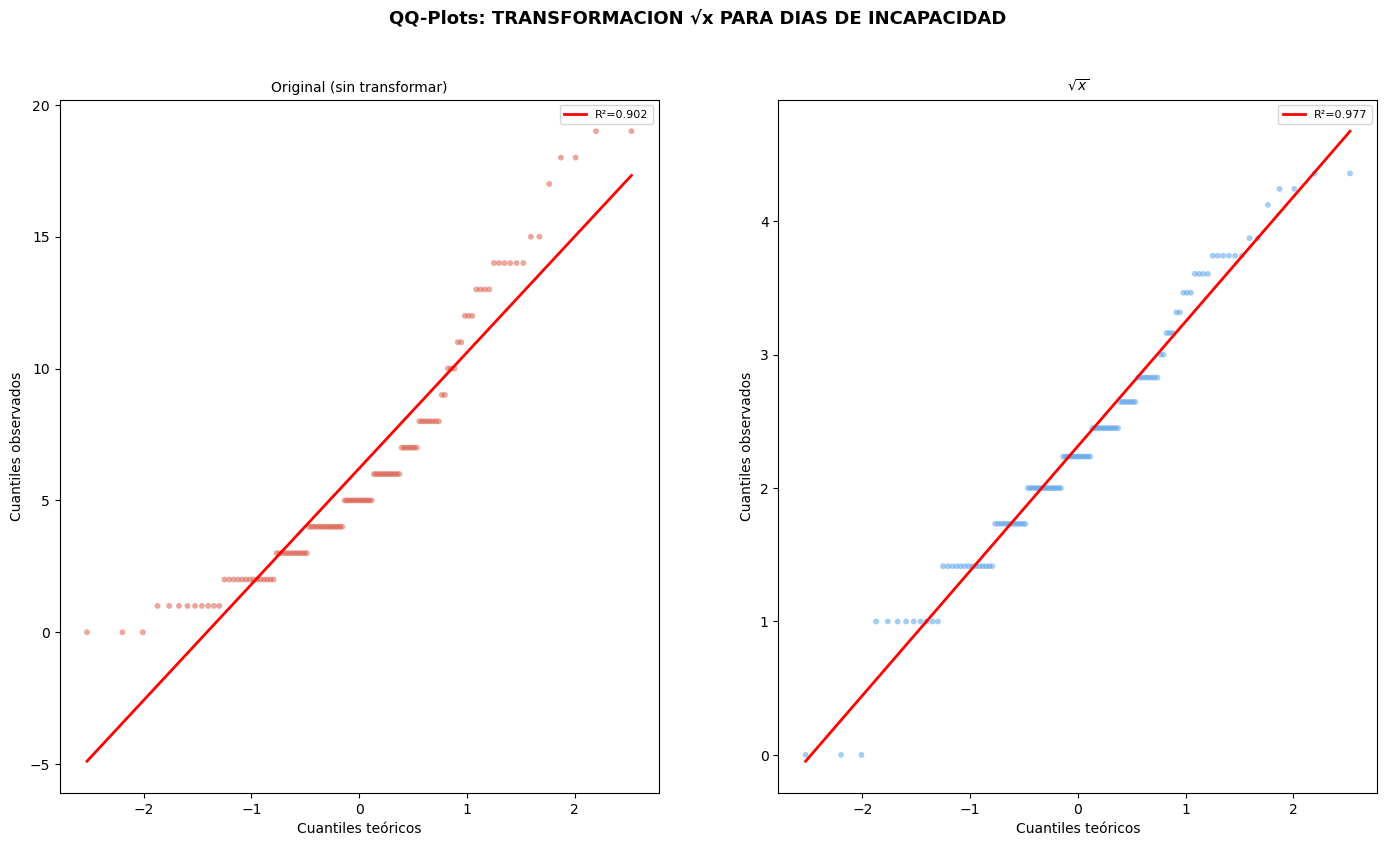

In [3]:
# ============================================================
# EJERCICIO 2 — Datos provistos
# ============================================================

np.random.seed(77)

n_empleados = 120
sucursales = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'],
                               n_empleados)

# Siniestros de incapacidad (días ausentes en el año)
dias_base = {'Norte': 3, 'Sur': 4, 'Este': 5, 'Oeste': 3, 'Centro': 12}  # Centro es alta frecuencia
num_siniestros_ej2 = np.array([
    np.random.poisson(dias_base[s]) for s in sucursales
])

df_vida_grupo = pd.DataFrame({
    'Empleado_ID': range(1, n_empleados+1),
    'Sucursal': sucursales,
    'Dias_Incapacidad': num_siniestros_ej2
})

print(f'Dataset: {len(df_vida_grupo)} empleados en {df_vida_grupo.Sucursal.nunique()} sucursales')
print('\nResumen por sucursal:')
print(df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].describe().round(2))

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

print()
print("=======================================================")
print("============== SOLUCION EJERCICIO 2 ===================")
print("=======================================================")
print()

# =============================================
# ====== 1. FRECUENCIAS ATIPICAS CON IQR ======
#==============================================

out2_iqr, ind2_iqr = iqr(df_vida_grupo['Dias_Incapacidad'])
print("===== OUTLIERS CON IQR PARA DATOS ORIGINALES ======")
for i,j in zip(out2_iqr, ind2_iqr):
    print(f"Dato numero {j} - Dias de incapacidad: {i:,} - Sucursal: {df_vida_grupo['Sucursal'][j]}")
print(f"Total de Outliers: {len(out2_iqr)}")
print()

# ===============================================================
# ====== 2. TRANSFORMAMOS CON RAIZ Y RECALCULAMOS OUTLIERS ======
#================================================================

trans2_raiz = trans_raiz(df_vida_grupo['Dias_Incapacidad'])
out2_raiz, ind2_raiz = iqr(trans2_raiz)
print("===== OUTLIERS (IQR) PARA DATOS TRANSFORMADOS CON √x ======")
for i,j in zip(out2_raiz, ind2_raiz):
    print(f"Dato numero {j} - Dias de incapacidad: {i:,} - Sucursal: {df_vida_grupo['Sucursal'][j]}")
print(f"Total de Outliers: {len(out2_raiz)}")
print()

# ==================== HACEMOS QQ-PLOT ====================
fig, axes = plt.subplots(1, 2, figsize=(17, 9))
fig.suptitle('QQ-Plots: TRANSFORMACION √x PARA DIAS DE INCAPACIDAD',
             fontsize=13, fontweight='bold')

axes_flat = axes.flat
configs = [
    ('Original (sin transformar)',  '#D94F3D', df_vida_grupo['Dias_Incapacidad']),
    ('$\\sqrt{x}$',                 '#4C9BE8', trans2_raiz)
]

for (titulo, color, trans), ax in zip(configs, axes_flat):
    qq_plot(titulo, color, trans, ax)

# ===========================================
# ====== 3. TASA RELATIVA POR SUCURSAL ======
#============================================

prom_global = df_vida_grupo['Dias_Incapacidad'].mean()

t_relativas = df_vida_grupo.groupby('Sucursal').agg(
    promedio = ('Dias_Incapacidad', 'mean'),
    maximo = ('Dias_Incapacidad', 'max'),
    tamanio = ('Empleado_ID', 'count')
    )
t_relativas['tasa_relativa_global'] = t_relativas['promedio'] / prom_global
t_relativas['tasa_relativa'] = t_relativas['promedio'] / max(t_relativas['promedio'])

print("============= TASAS RELATIVAS =============")
print(t_relativas.to_string())

# ============================================================
# ===== 4. APLICAMOS ARCSIN(√pj) Y CONSTRUIMOS IC AL 95% =====
#=============================================================

# ================= TRANSFORMACION =================
def t_arcsin_raiz(datos):
    return np.arcsin(np.sqrt(np.clip(datos, 0, 1)))

tasas_arcsin = t_arcsin_raiz(t_relativas['tasa_relativa'])

# ============== OBTENEMOS IC AL 95% ==============

df_ic = pd.DataFrame({
    'pj': t_relativas['tasa_relativa'],
    'pj_trans': tasas_arcsin,
    'nj': t_relativas['tamanio']
})

# Calculamos el Margen de Error en la escala transformada
# Z = 1.96 para el 95% de confianza. Varianza = 1 / (4 * n_j)
var = 1 / (4 * df_ic['nj'])
dvs = np.sqrt(1 / (4 * df_ic['nj']))
error_transformado = 1.96 * np.sqrt(1 / (4 * df_ic['nj']))

# Límites en la escala transformada
li_trans = df_ic['pj_trans'] - error_transformado
ls_trans = df_ic['pj_trans'] + error_transformado

# Regresamos a la escala original usando seno al cuadrado
# Agregamos clip para evitar valores fuera de [0, 1] tras la resta/suma
df_ic['IC_Inferior_95'] = np.sin(np.clip(li_trans, 0, np.pi/2)) ** 2
df_ic['IC_Superior_95'] = np.sin(np.clip(ls_trans, 0, np.pi/2)) ** 2

print("\n============= INTERVALOS DE CONFIANZA AL 95% =============")
print(df_ic[['pj', 'nj', 'IC_Inferior_95', 'IC_Superior_95']].to_string(formatters={
    'pj': '{:,.4f}'.format,
    'IC_Inferior_95': '{:,.4f}'.format,
    'IC_Superior_95': '{:,.4f}'.format
}))

# =====================================
# ========== 5. CONCLUSIONES ==========
#======================================

# En el punto uno calculamos los outliers de forma global, es decir, considerando todas las sucursales y datos.
# Podemos observar que los outliers resultantes son aquellos que muestran días de incapacidad mayores a 17 días
# Sin embargo, todos son de la sucursal Centro, los cuales cuentan con una media signiticativamente mas 
# grande que las demas sucursales. En comparación con las demas sucursales, la sucursal Centro muestra más 
# datos atipicos de forma global.
# Al transformar los datos utilizando raiz cuadrada, los outliers resultantes corresponden a aquellos datos
# con dias de incapacidad iguales a cero, pero no se tiene ningun outlier que coincida con los datos origi-
# nales. Esto significa que la transformacion ha reducido esa dispersion inicial. Ademas, el grafico nos
# muestra que la R^2 es bastante cercana a uno, por lo que se trata de un buen ajuste de los datos. Es im-
# portante notar que, despues de la transformacion, la sucursal Centro dejo de mostrar un numero alto de 
# valores atipicos.
# Al calcular las tasas relativas, normalizamos el riesgo de la cartera, pues tomamos a la sucursal Centro
# como la base de maxima exposicion. Posteriormente, al aplicar arcsin de la raiz y usar la varianza estabi-
# lizada, logramos construir intervalos consistentes. En este punto, es posible observar que el intervalo de 
# confianza de la sucursal Centro es distinto a las de las demas sucursales, no se intersecta con los demas 
# intervalos, la amplitud es muy pequeña y se encuentra alejado del resto. Esto nos hace inferir, con un 95% 
# de confianza, que la sucursal Centro comunmente tiene frecuencias altas en comparación con las demas sucur-
# sales. Por lo tanto, aun despues de la transformacion de los datos y la normalizacion de las tasas relati-
# vas, la sucursal Centro continua mostrando cierto comportamiento atipico de forma global.

---
## Ejercicio 3 — Seguro de Hogar: Frecuencia + Severidad + Transformaciones

**Enunciado**

Portafolio de **130 pólizas** de hogar. Algunas pólizas no tuvieron siniestros (monto = 0).

1. Detecta outliers de frecuencia (IQR) y severidad (IQR) en escala original
2. Calcula la prima pura en 4 escenarios (con/sin outliers en cada dimensión)
3. Aplica `√x` a frecuencia y `arcsinh(x/mediana)` a severidad
4. Construye tabla comparativa de asimetría/curtosis antes y después
5. Detecta doble outlier en escala transformada: ¿coincide con el original?
6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?


Dataset: 130 pólizas de hogar

Estadísticas:
       Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
count     130.00          130.00              130.00       130.00
mean       65.50            2.01            41788.53    306729.88
std        37.67            2.29           116951.19   1095056.71
min         1.00            0.00             2512.53         0.00
25%        33.25            1.00             5307.03      4217.53
50%        65.50            1.00             8424.76     10984.94
75%        97.75            2.00            11782.46     21785.43
max       130.00           12.00           600000.00   7200000.00

============== SOLUCION EJERCICIO 3 ===================

===== OUTLIERS (IQR) FRECUENCIA ======
Dato numero 7 - Siniestros: 4
Dato numero 16 - Siniestros: 4
Dato numero 55 - Siniestros: 4
Dato numero 72 - Siniestros: 5
Dato numero 85 - Siniestros: 4
Dato numero 106 - Siniestros: 4
Dato numero 107 - Siniestros: 4
Dato numero 118 - Siniestros: 4
Dato numero 12

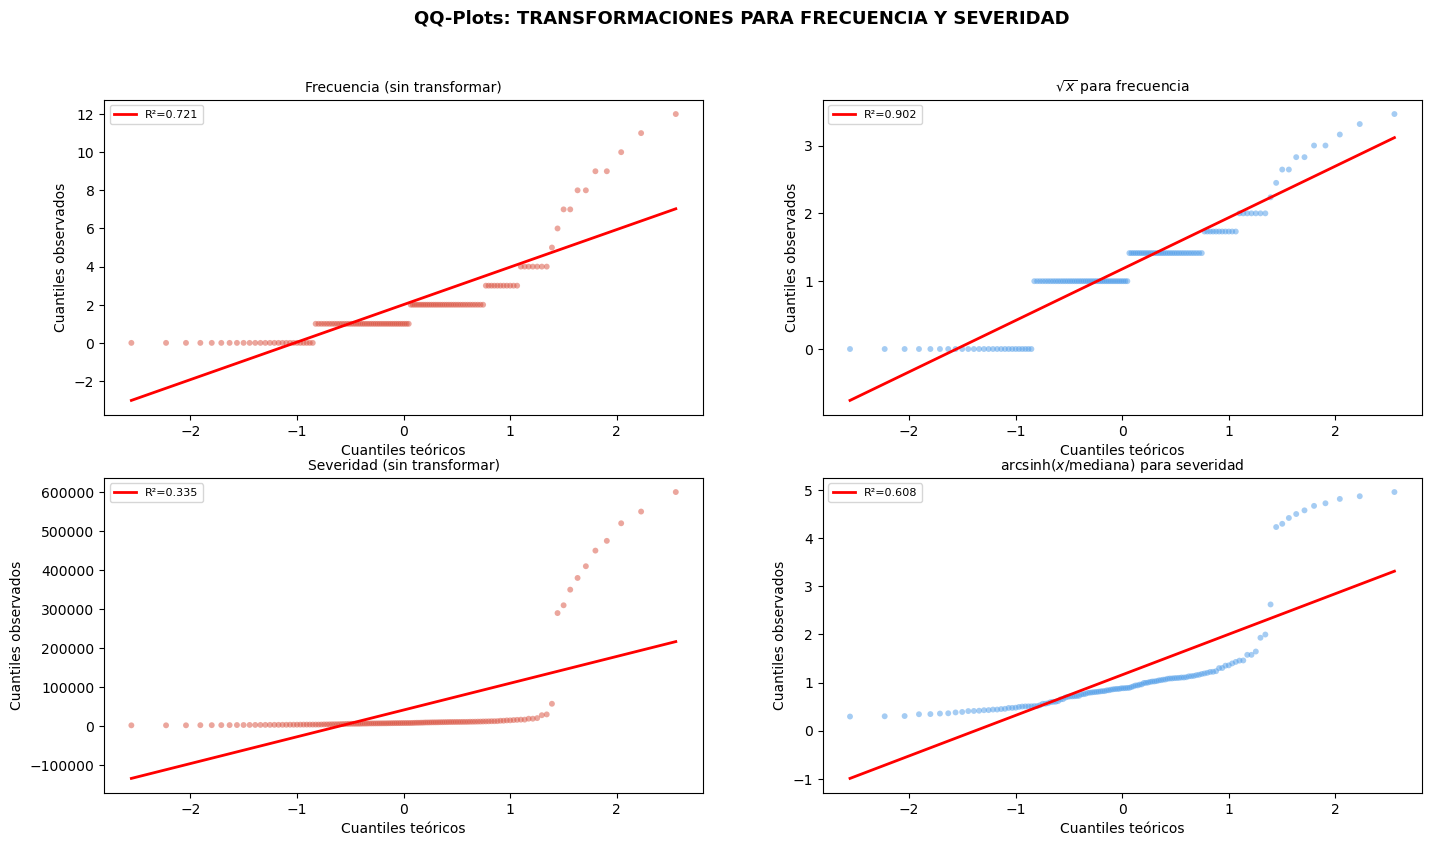

In [ ]:
# ============================================================
# EJERCICIO 3 — Datos provistos
# ============================================================

np.random.seed(55)
n_polizas = 130

# Frecuencia: Poisson(1.5) con algunos outliers
freq_hogar = pd.Series(
    np.concatenate([
        np.random.poisson(1.5, 120),
        np.array([8, 10, 7, 9, 12, 6, 11, 8, 9, 7])
    ])
)

# Severidad promedio por póliza (MXN)
sev_hogar = pd.Series(
    np.concatenate([
        np.random.lognormal(9.0, 0.6, 120),
        np.array([450_000, 380_000, 520_000, 310_000, 600_000,
                  290_000, 475_000, 350_000, 410_000, 550_000])
    ])
).round(2)

df_hogar = pd.DataFrame({
    'Poliza_ID': range(1, n_polizas + 1),
    'Num_Siniestros': freq_hogar,
    'Monto_Promedio_MXN': sev_hogar
})
df_hogar['Costo_Total'] = df_hogar['Num_Siniestros'] * df_hogar['Monto_Promedio_MXN']

print(f'Dataset: {len(df_hogar)} pólizas de hogar')
print('\nEstadísticas:')
print(df_hogar.describe().round(2))

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

print()
print("=======================================================")
print("============== SOLUCION EJERCICIO 3 ===================")
print("=======================================================")
print()

# =====================================================
# ==== 1. OUTLIERS DE FRECUENCIA Y SEVERIDAD (IQR) ====
#======================================================

frec_out, frec_ind = iqr(df_hogar['Num_Siniestros'])
sev_out, sev_ind = iqr(df_hogar['Monto_Promedio_MXN'])

print("===== OUTLIERS (IQR) FRECUENCIA ======")
for i,j in zip(frec_out, frec_ind):
    print(f"Dato numero {j} - Siniestros: {i:,}")
print(f"Total de Outliers: {len(frec_out)}")
print()

print("===== OUTLIERS (IQR) SEVERIDAD ======")
for i,j in zip(sev_out, sev_ind):
    print(f"Dato numero {j} - Monto: ${i:,}")
print(f"Total de Outliers: {len(sev_out)}")
print()

# =================================================
# ======== 2. PRIMA PURA CUATRO ESCENARIOS ========
#==================================================

# ======== CON OUTLIERS EN FRECUENCIA Y SEVERIDAD ========
p_pura_con = df_hogar['Costo_Total'].sum() / n_polizas

# ======== SIN OUTLIERS EN FRECUENCIA ========
p_pura_frec_sin = df_hogar.drop(index=frec_ind)['Costo_Total'].sum() / n_polizas

# ======== SIN OUTLIERS EN SEVERIDAD ========
p_pura_sev_sin = df_hogar.drop(index=sev_ind)['Costo_Total'].sum() / n_polizas 

# ======== SIN OUTLIERS EN FRECUENCIA Y SEVERIDAD ========
# Juntamos ambos índices usando unión de conjuntos para no repetir filas
todos_los_outliers = list(set(frec_ind) | set(sev_ind))
p_pura_sin = df_hogar.drop(index=todos_los_outliers)['Costo_Total'].sum() / n_polizas

print("================= PRIMA PURA CUATRO ESCENARIOS =================")
print(f"{'Prima Pura CON Outliers:':>40} ${p_pura_con:,.2f} MXN")
print(f"{'Prima Pura SIN Outliers en frecuencia:':>40} ${p_pura_frec_sin:,.2f} MXN")
print(f"{'Prima Pura SIN Outliers en severidad:':>40} ${p_pura_sev_sin:,.2f} MXN")
print(f"{'Prima Pura SIN Outliers en ambos:':>40} ${p_pura_sin:,.2f} MXN")
print()

# ================================================
# ======== 3. APLICAMOS √x A FRECUENCIA Y ========
# ======== arcsinh(x/mediana) A SEVERIDAD ========
#=================================================

frec_raiz = trans_raiz(df_hogar['Num_Siniestros'])
escala_sev = df_hogar[df_hogar['Monto_Promedio_MXN']>0]['Monto_Promedio_MXN'].median()
sev_arcsin = trans_arcsinh(df_hogar['Monto_Promedio_MXN'], escala_sev)

fig, axes = plt.subplots(2, 2, figsize=(17, 9))
fig.suptitle('QQ-Plots: TRANSFORMACIONES PARA FRECUENCIA Y SEVERIDAD',
             fontsize=13, fontweight='bold')

axes_flat = axes.flat
configs = [
    ('Frecuencia (sin transformar)',    '#D94F3D', df_hogar['Num_Siniestros']),
    ('$\\sqrt{x}$ para frecuencia',     '#4C9BE8', frec_raiz),
    ('Severidad (sin transformar)',     '#D94F3D', df_hogar['Monto_Promedio_MXN']),
    ('$\\text{arcsinh}(x/\\text{mediana}$) para severidad', '#4C9BE8', sev_arcsin),  
]

for (titulo, color, trans), ax in zip(configs, axes_flat):
    qq_plot(titulo, color, trans, ax)

# ==========================================================
# ====== 4. TABLA COMPARATIVA DE ASIMETRIA Y CURTOSIS ======
# ==========================================================

print("===== TABLA COMPARATIVA ASIMETRIA Y CURTOSIS ======")

tabla_comp = {
    'Dato' : [
        'Frecuencia', 
        'Frecuencia transformada', 
        'Severidad', 
        'Severidad transformada'
    ],
    'Asimetria': [
        df_hogar['Num_Siniestros'].skew(), 
        frec_raiz.skew(),
        df_hogar['Monto_Promedio_MXN'].skew(), 
        sev_arcsin.skew()
    ],
    'Curtosis': [
        df_hogar['Num_Siniestros'].kurtosis(), 
        frec_raiz.kurtosis(), 
        df_hogar['Monto_Promedio_MXN'].kurtosis(),
        sev_arcsin.kurtosis()
    ]
}

# Lo convertimos a DataFrame
df_comparativo = pd.DataFrame(tabla_comp)
print(df_comparativo)
print()

# =============================================================
# ======== 5. OUTLIERS DOBLES EN ESCALAS TRANSFORMADAS ========
# =============================================================

out_frec_raiz, ind_frec_raiz = iqr(frec_raiz)
out_sev_arcsin, ind_sev_arcsin = iqr(sev_arcsin)

print("===== OUTLIERS (IQR) FRECUENCIA √x ======")
for i,j in zip(out_frec_raiz, ind_frec_raiz):
    print(f"Dato numero {j} - Siniestros: {i:.4f}")
print(f"Total de Outliers: {len(out_frec_raiz)}")
print()

print("===== OUTLIERS (IQR) SEVERIDAD arcsinh(x/mediana) ======")
for i,j in zip(out_sev_arcsin, ind_sev_arcsin):
    print(f"Dato numero {j} - Monto: ${i:.4f}")
print(f"Total de Outliers: {len(out_sev_arcsin)}")
print()

indices_interseccion = np.intersect1d(ind_frec_raiz, ind_sev_arcsin)

print("===== OUTLIERS (IQR) FRECUENCIA Y SEVERIDAD TRANSFORMADOS ======")
print(f"{'Índice':<6} | {'Frec. Trans':<12} | {'Frec. Orig':<11} | {'Sev. Trans':<12} | {'Sev. Original':<15}")
print("-" * 65) # Una línea separadora para darle un toque profesional
for idx in indices_interseccion:
    f_val = frec_raiz[idx]
    s_val = sev_arcsin[idx]
    f_or  = df_hogar['Num_Siniestros'][idx]
    s_or  = df_hogar['Monto_Promedio_MXN'][idx]
    print(f"{idx:<6} | {f_val:<12.4f} | {f_or:<11.0f} | {s_val:<12.4f} | ${s_or:<14,.2f}")
print("-" * 65)
print(f"Total de Outliers: {len(indices_interseccion)}")
print()

# ===================================================================
# ======== 6. CONCLUSIONES Y DISCUSION DESIGUALDAD DE JENSEN ========
# ===================================================================

# En el primer punto podemos observar que la frecuencia tiene un total de 18 outliers, que en su mayoria
# son los datos más grandes comparados con el resto, pues la media son 2 siniestros y los outliers son 
# aquellos que sobrepasan los 4 siniestros. Por otro lado, la severidad tiene 13 outliers que se componen
# por montos mayores. Los montos más grandes que podemos encontrar estan entre los $400,000 hasta los $600,000.
# Al calcular la prima pura con outliers obtenemos un monto bastante grande: $306,729.88 y al utilizar los
# datos sin outliers los costos disminuyen considerablemente, desde $9,000 hasta $11,600 aproximadamente.
# Al aplicar la raiz a la frecuencia podemos notar, con ayuda de los QQ-Plots construidos, que los datos
# se ajustaron bastante bien con una R^2 bastante cercana a 1 y con la tabla comparativa del punto 4, vemos 
# que la asimetria disminuyó de 2.3 a 0.37, lo cual es un muy buen resultado, nos indica que la distribucion
# es mas simetrica. Algo similar ocurre con la curtosis, disminuyo de 5.8 a 0.4, esto significa que ya no hay 
# colas tan pesadas. Para la severidad utilizamos el arcoseno hiperbolico de los datos escalados con la me-
# diana. Los datos lograron ajustarse con una R^2 igual a 0.6, disminuyó la asimetria de 3.5 a 2.6 y la cur-
# tosis de 11.1 a 6.09, esto implica que ya no se tienen colas tan pesadas. 
# En el punto 5 al detectar los outliers de las variables transformadas podemos observar algo con los outliers 
# de la frecuencia: muchos son cero. Esto se debe a que muchas frecuencias originalmente eran cero. Al trans-
# formarlas con raiz cuadrada se mantuvieron en cero y al momento de definir el intervalo con el metodo IQR, 
# esos ceros se clasificaron como outliers. Sin embargo, no sería correcto considerarlos como tal, pues no 
# significan un riesgo en el contexto asegurador. En cuanto a los demás datos distintos de cero, observemos 
# que aquellos datos grandes (indices entre 120 a 129) mayores de 4, aun siguen clasificandose como outliers. 
# Los montos transformados de igual forma, siguen manteniendo los outliers entre los indices 120-129. 
# Al momento de buscar la interseccion de ambos outliers encontramos aquellos que originalmente, sin trans-
# formar los datos, ya eran outliers. 
# Finalmente, en cuanto a la Desigualdad de Jensen, considero que no es correcto usar el arcsenh para calcular
# la prima. Como se vio en clase, transformar para modelar es diferente a transformar para tarifar. 
# Si calculamos la prima pura obteniendo el promedio de los datos transformados y luego aplicamos la función 
# inversa directa a ese resultado, estaríamos realizando una subestimación del riesgo. No sería correcto usar
# los datos transformados para fijar precios que cubran las colas pesadas. Las transformaciones deben usarse 
# únicamente como herramientas de diagnóstico y normalización lineal, pero tomando en cuenta siempre la escala 
# real del dinero al momento de tarifar.